# CTM Robustness Check

Validates the key BERTopic findings from `topic_demographic_relationship.ipynb` using CombinedTM (CTM) as an independent second topic model.

The comparison targets **merged BERTopic topics** — the same analytical units used in the Spearman demographic analysis — rather than raw sub-topics, so the lexical check directly validates what is claimed.

Pipeline:
1. Load BERTopic top-word sets and merge them by label (union of all sub-topics sharing the same human-readable label).
2. Load CTM topic word sets (`ctm_topic_words.csv`).
3. Compute Jaccard similarity against all CTM topics for **every** merged BERTopic topic; record the **best-matching** CTM topic and score.
4. Examine whether CI-significant topics (from the Spearman demographic analysis) show systematically different CTM alignment than non-significant topics.
5. Visualize model-level metrics, the |ρ| vs Jaccard scatter across all topics, and the full Jaccard ranking.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_colwidth', 120)
plt.rcParams['axes.grid'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Robust project-root discovery: works even if notebook is nested (e.g., src/analyisis)
start = Path.cwd().resolve()
ROOT = None
for cand in [start, *start.parents]:
    if (cand / 'src').exists() and (cand / 'results').exists():
        ROOT = cand
        break
if ROOT is None:
    raise RuntimeError('Could not locate project root containing both src/ and results/.')

SRC_DIR = ROOT / 'src'
QUAL_DIR = ROOT / 'results' / 'qualitative'
TOPIC_DIR = SRC_DIR / 'topic_modeling' / 'results'

SUMMARY_DIR = ROOT / 'results' / 'summary'

print('ROOT:', ROOT)
print('QUAL_DIR exists:', QUAL_DIR.exists())
print('SUMMARY_DIR:', SUMMARY_DIR)
print('TOPIC_DIR exists:', TOPIC_DIR.exists())


ROOT: /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis
QUAL_DIR exists: True
SUMMARY_DIR: /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary
TOPIC_DIR exists: True


## 1. CTM Robustness: Lexicon Alignment

### 1.1 Introduction
CTM is used as an independent robustness check on the BERTopic demographic findings. The goal is not to replace BERTopic, but to test whether the CI-significant merged topics identified in the Spearman analysis are lexically reproducible under a structurally different model.

We compare against **merged** BERTopic topics (identical labels combined) for two reasons: (1) merging is the analytical unit in the Spearman analysis, and (2) pooling sub-topics' word sets strengthens the lexical signal, giving CTM the best chance of matching.

### 1.2 Metrics and Methods

**Model-level metrics** (pre-computed in `src/topic_modeling/ctm_robustness.ipynb`, loaded here for comparison):
- **Topic Coherence (c_v)**: measures how semantically coherent a topic's top words are by computing normalised pointwise mutual information (NPMI) between word pairs within a sliding window over the corpus. Higher coherence means the top words genuinely co-occur in documents and form a meaningful theme. Computed via `CoherenceCV` from the `contextualized_topic_models` library (Röder et al., 2015).
- **Topic Diversity**: proportion of unique words across all topics' top-word lists, i.e.,  `|unique words| / |total words|`. A score of 1.0 means every topic uses a completely distinct vocabulary; scores near 0 indicate severe overlap between topics. Computed as `len(set(all_top_words)) / len(all_top_words)` over all topics.

**Lexical alignment metrics** (computed in this notebook):
- **Merged BERTopic word set**: for each unique topic label, the top-word lists of all raw sub-topics sharing that label are split into individual tokens and unioned — giving one word set per logical topic.
- **Jaccard similarity**: for a merged BERTopic topic $B$ and a CTM topic $C$, $\text{Jaccard} = |B \cap C| / |B \cup C|$. We report the best-matching CTM topic (argmax Jaccard) for **every** merged BERTopic topic (71 total).
- **CI-significance label**: each topic is flagged `ci_sig = True` if its Spearman bootstrap CI excludes zero for at least one covariate.
- **Pattern analysis**: we compare the Jaccard distribution between CI-significant and non-significant topics to test whether demographically relevant topics are systematically under- or over-represented in CTM.


In [2]:
OUT_DIR = SUMMARY_DIR / 'CTM_robustness'
OUT_FIG_DIR = OUT_DIR / 'figures'
OUT_TAB_DIR = OUT_DIR / 'tables'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_TAB_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Model-level metrics ────────────────────────────────────────────────────
model_cmp = pd.read_csv(TOPIC_DIR / 'ctm_vs_bertopic_comparison.csv')

# ── 2. Build merged BERTopic word sets (word-level tokens, union per label) ───
rep = pd.read_csv(TOPIC_DIR / 'representative_prompts_labeled.csv')
bert_words_raw = rep[['topic_id', 'topic_label', 'top_words']].drop_duplicates('topic_id').copy()

def to_word_tokens(s):
    """Split comma-separated keyphrases into individual word tokens."""
    tokens = set()
    for phrase in str(s).split(','):
        for w in phrase.strip().lower().split():
            if w:
                tokens.add(w)
    return tokens

bert_words_raw['word_set'] = bert_words_raw['top_words'].apply(to_word_tokens)
merged_word_sets = (
    bert_words_raw.groupby('topic_label')['word_set']
    .apply(lambda sets: set().union(*sets))
    .reset_index()
    .rename(columns={'word_set': 'bert_words'})
)
# Track number of sub-topics per merged label
n_subtopics = bert_words_raw.groupby('topic_label').size().rename('n_subtopics')
merged_word_sets = merged_word_sets.join(n_subtopics, on='topic_label')
print(f'Merged BERTopic topic labels: {len(merged_word_sets)}')

# ── 3. Load CTM topic word sets ───────────────────────────────────────────────
ctm_df = pd.read_csv(TOPIC_DIR / 'ctm_topic_words.csv')
ctm_df['word_set'] = ctm_df['top_words'].apply(to_word_tokens)

def best_ctm_match(bert_set):
    """Return (ctm_topic_id, jaccard) for the best-matching CTM topic."""
    best_j, best_id = 0.0, -1
    for _, row in ctm_df.iterrows():
        c = row['word_set']
        union = bert_set | c
        if not union:
            continue
        j = len(bert_set & c) / len(union)
        if j > best_j:
            best_j, best_id = j, int(row['topic_id'])
    return best_id, best_j

# ── 4. Load Spearman results — best |ρ| per merged topic ─────────────────────
sp_path = SUMMARY_DIR / 'topic_demographic_relationship' / 'tables' / 'spearman_merged_topic_covariates.csv'
spearman = pd.read_csv(sp_path)
ci_sig_labels = set(spearman[spearman['ci_sig']]['topic_label'])

sp_best = (
    spearman.assign(abs_rho=lambda d: d['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
    .drop_duplicates('topic_label')
    .set_index('topic_label')
)

# ── 5. Compute Jaccard for ALL merged topics ──────────────────────────────────
rows = []
for _, r in merged_word_sets.iterrows():
    label = r['topic_label']
    ctm_id, jac = best_ctm_match(r['bert_words'])
    sp_row = sp_best.loc[label] if label in sp_best.index else None
    rows.append({
        'topic_label':  label,
        'super_topic':  sp_row['super_topic']  if sp_row is not None else 'Unknown',
        'abs_rho':      sp_row['abs_rho']      if sp_row is not None else 0.0,
        'spearman_rho': sp_row['spearman_rho'] if sp_row is not None else 0.0,
        'ci_sig':       label in ci_sig_labels,
        'fdr_q_value':  sp_row['fdr_q_value']  if sp_row is not None else None,
        'n_subtopics':  int(r['n_subtopics']),
        'ctm_topic_id': ctm_id,
        'jaccard':      round(jac, 4),
    })

all_topics = pd.DataFrame(rows).sort_values('jaccard', ascending=False).reset_index(drop=True)
ctm_key = all_topics[all_topics['ci_sig']].reset_index(drop=True)  # CI-sig subset for display

# ── 6. Save ───────────────────────────────────────────────────────────────────
model_cmp.to_csv(OUT_TAB_DIR / 'ctm_vs_bertopic_comparison.csv', index=False)
all_topics.to_csv(OUT_TAB_DIR / 'ctm_robustness_all_merged_topics.csv', index=False)
ctm_key.to_csv(OUT_TAB_DIR / 'ctm_robustness_merged_ci_significant.csv', index=False)

# ── 7. Summary stats ──────────────────────────────────────────────────────────
print('Model-level comparison')
display(model_cmp)

print(f'\nAll {len(all_topics)} merged topics — Jaccard summary:')
print(f'  Topics with Jaccard > 0 :  {(all_topics["jaccard"] > 0).sum()}')
print(f'  Max Jaccard             :  {all_topics["jaccard"].max():.4f}')
print(f'  Median Jaccard          :  {all_topics["jaccard"].median():.4f}')
grp = all_topics.groupby('ci_sig')['jaccard'].agg(['mean','median','max'])
print(f'\nJaccard by CI-significance:\n{grp}')

print('\nCI-significant topics (focus set):')
display(ctm_key[['topic_label','spearman_rho','ci_sig','ctm_topic_id','jaccard']])

print('\nTop-10 best-aligned topics overall:')
display(all_topics[['topic_label','abs_rho','ci_sig','ctm_topic_id','jaccard']].head(10))


Merged BERTopic topic labels: 71
Model-level comparison


,model,n_topics,coherence_cv,diversity,outlier_rate,notes
0,BERTopic (run_04),76,0.5806,0.8408,0.4493,"min_topic_size=100, n_neighbors=15"
1,CombinedTM,76,0.4821,0.6132,NaN,"n_components=76, epochs=100"



All 71 merged topics — Jaccard summary:
  Topics with Jaccard > 0 :  47
  Max Jaccard             :  0.5000
  Median Jaccard          :  0.0588

Jaccard by CI-significance:
            mean  median     max
ci_sig                          
False   0.070833  0.0588  0.5000
True    0.044100  0.0588  0.0588

CI-significant topics (focus set):


,topic_label,spearman_rho,ci_sig,ctm_topic_id,jaccard
0,Game Concept Ideation,0.439919,True,59,0.0588
1,SCP Creative Writing,0.532860,True,36,0.0588
2,Image Generation Requests,-0.517755,True,55,0.0588
3,AI Art Prompting,0.399871,True,-1,0.0000



Top-10 best-aligned topics overall:


,topic_label,abs_rho,ci_sig,ctm_topic_id,jaccard
0,Game Dev Scripting,0.096801,False,52,0.5000
1,Career Resume Help,0.077992,False,7,0.2857
2,Character Fusion Descriptions,0.190469,False,59,0.2857
3,Political History Questions,0.178413,False,40,0.2000
4,Math Problem Solving,0.297483,False,37,0.2000
5,Fetish Comedy Stories,0.249650,False,65,0.2000
6,Customer Service Emails,0.246153,False,57,0.1429
7,Sports Script Writing,0.069165,False,12,0.1333
8,Adult Fantasy Fiction,0.137891,False,25,0.1333
9,Azur Lane Roleplay,0.213997,False,21,0.1333


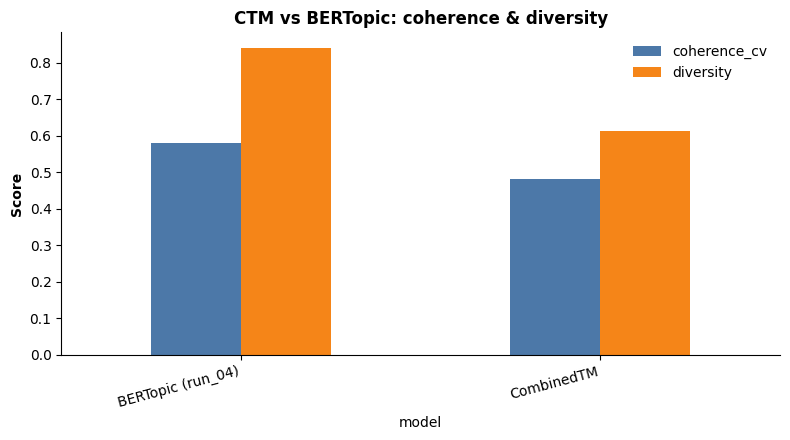

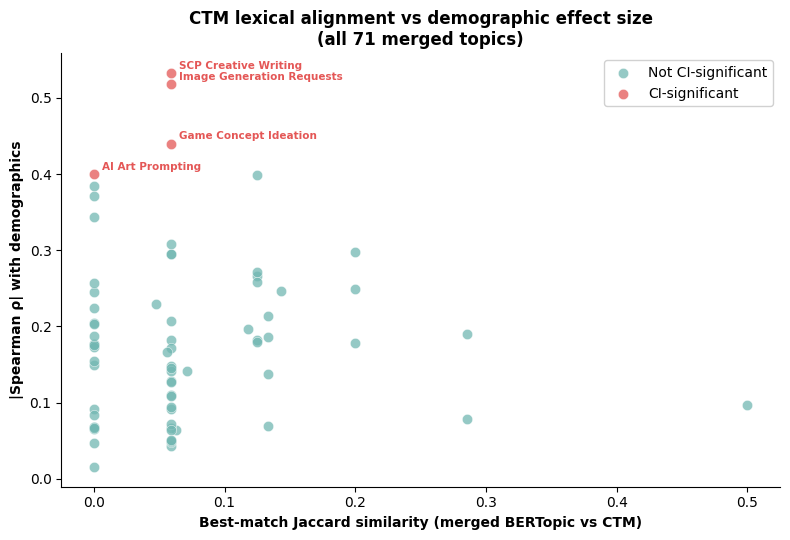

/var/folders/xm/5nkqyhbd0svb9crvs4w40bmh0000gn/T/ipykernel_60053/1068334722.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


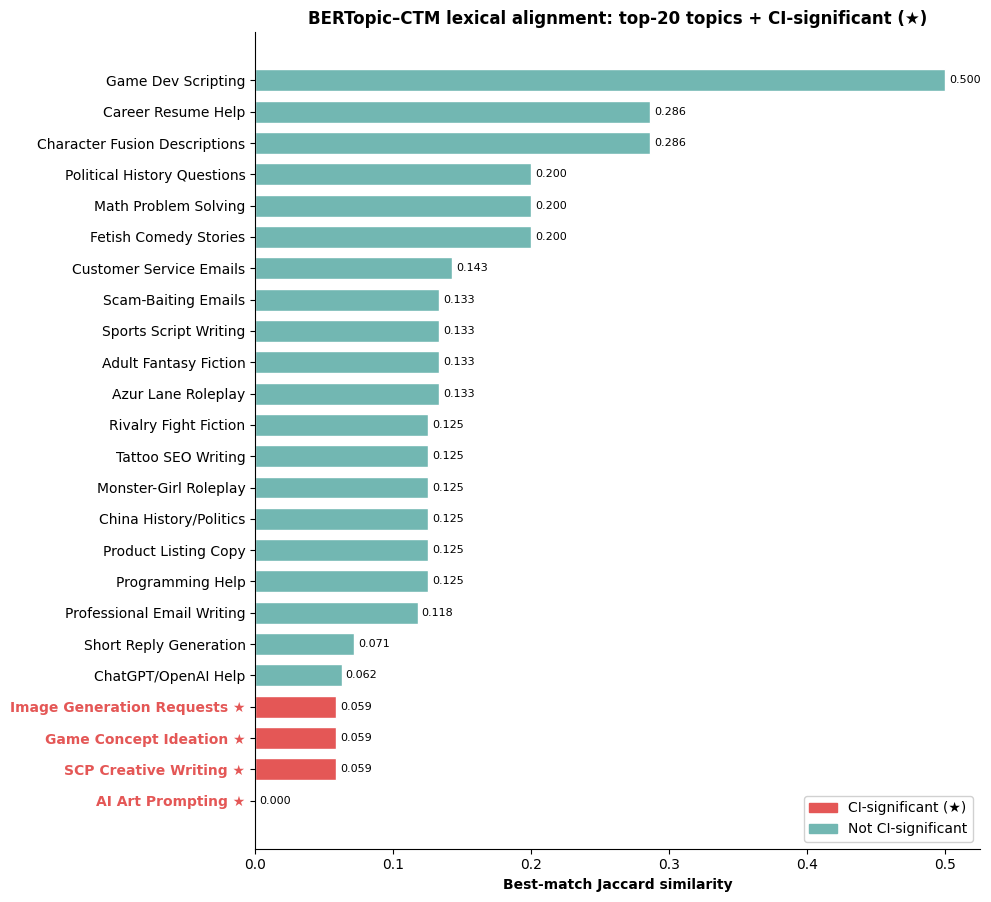

Saved figures to /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary/CTM_robustness/figures


In [3]:
import matplotlib.patches as mpatches

SIG_COLOR   = '#E45756'   # red — CI-significant
NSIG_COLOR  = '#72B7B2'   # teal — not significant

# ── Fig 1: Model-level metric comparison ─────────────────────────────────────
metrics = ['coherence_cv', 'diversity']
plot_df = model_cmp.set_index('model')[metrics]

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df.plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518'])
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('CTM vs BERTopic: coherence & diversity', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(frameon=False)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_FIG_DIR / 'fig1_ctm_vs_bertopic_metrics.png', dpi=220, bbox_inches='tight')
plt.show()

# ── Fig 2: |ρ| vs Jaccard scatter (all merged topics) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
for ci, grp in all_topics.groupby('ci_sig'):
    color = SIG_COLOR if ci else NSIG_COLOR
    label = 'CI-significant' if ci else 'Not CI-significant'
    ax.scatter(grp['jaccard'], grp['abs_rho'], color=color, alpha=0.75,
               s=55, edgecolors='white', linewidths=0.4, label=label, zorder=3)

# Annotate CI-significant topics
for _, r in all_topics[all_topics['ci_sig']].iterrows():
    ax.annotate(r['topic_label'], xy=(r['jaccard'], r['abs_rho']),
                xytext=(6, 3), textcoords='offset points', fontsize=7.5,
                color=SIG_COLOR, fontweight='bold')

ax.set_xlabel('Best-match Jaccard similarity (merged BERTopic vs CTM)', fontweight='bold')
ax.set_ylabel('|Spearman ρ| with demographics', fontweight='bold')
ax.set_title('CTM lexical alignment vs demographic effect size\n(all 71 merged topics)',
             fontweight='bold')
ax.legend(frameon=True, framealpha=0.9)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_FIG_DIR / 'fig2_alignment_vs_effect_size.png', dpi=220, bbox_inches='tight')
plt.show()

# ── Fig 3: Full Jaccard ranking (top-20 + all CI-significant) ────────────────
# Include top-20 by Jaccard and ensure CI-significant topics appear
top20 = all_topics.head(20)
ci_rows = all_topics[all_topics['ci_sig'] & ~all_topics['topic_label'].isin(top20['topic_label'])]
plot_d = pd.concat([top20, ci_rows]).drop_duplicates('topic_label').sort_values('jaccard').reset_index(drop=True)

colors = [SIG_COLOR if ci else NSIG_COLOR for ci in plot_d['ci_sig']]
fig, ax = plt.subplots(figsize=(10, max(5, 0.38 * len(plot_d))))
bars = ax.barh(plot_d['topic_label'], plot_d['jaccard'], color=colors,
               edgecolor='white', height=0.7)
for bar, val in zip(bars, plot_d['jaccard']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('Best-match Jaccard similarity', fontweight='bold')
ax.set_title('BERTopic–CTM lexical alignment: top-20 topics + CI-significant (★)',
             fontweight='bold')

# Mark CI-significant with ★ suffix on y-axis labels
labels = [f'{l} ★' if ci else l
          for l, ci in zip(plot_d['topic_label'], plot_d['ci_sig'])]
ax.set_yticklabels(labels)
for tick, ci in zip(ax.get_yticklabels(), plot_d['ci_sig']):
    if ci:
        tick.set_color(SIG_COLOR)
        tick.set_fontweight('bold')

legend_patches = [
    mpatches.Patch(color=SIG_COLOR,  label='CI-significant (★)'),
    mpatches.Patch(color=NSIG_COLOR, label='Not CI-significant'),
]
ax.legend(handles=legend_patches, frameon=True, framealpha=0.9)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig(OUT_FIG_DIR / 'fig3_full_jaccard_ranking.png', dpi=220, bbox_inches='tight')
plt.show()

print('Saved figures to', OUT_FIG_DIR)


## 2. Conclusion

**CTM alignment is generally low across all 71 merged BERTopic topics, but there is a clear negative pattern: CI-significant topics cluster at the bottom of the Jaccard distribution.**

- Non-significant topics achieve Jaccard up to **0.50** (Game Dev Scripting), with many in the 0.10–0.30 range.
- All four CI-significant topics score ≤ 0.059 — at or near zero.

The three non-zero CI-significant scores (0.059) each reflect a single incidental token overlap with a semantically unrelated CTM topic:

| BERTopic topic | Best CTM match (content) | Shared token |
|---|---|---|
| SCP Creative Writing | CTM-36 (ML / dataframes) | `test` |
| Image Generation Requests | CTM-55 (chatbot / assistant) | `draw` |
| Game Concept Ideation | CTM-59 (casual outfit suggestions) | `names` |
| AI Art Prompting | — | none |

This is a **CTM quality limitation**, not evidence against the BERTopic findings. BERTopic shows higher coherence (0.58 vs 0.48) and substantially higher diversity (0.84 vs 0.61). A better-tuned CTM with a richer vocabulary, deduplicated topics, and proper hyperparameter tuning would be needed for a genuine independent lexical replication.